In [ ]:
pip install scikit-rf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.1/627.1 kB 9.6 MB/s eta 0:00:00


In [ ]:
import skrf as rf
import matplotlib.pyplot as plt
import os

# Obtener una lista de todos los archivos .s2p en el directorio actual
s2p_files = [f for f in os.listdir('.') if f.endswith('.s2p')]

if not s2p_files:
    print("No se encontraron archivos .s2p en el directorio actual.")
else:
    print(f"Se encontraron los siguientes archivos .s2p: {s2p_files}")

    # Lista para almacenar todas las redes cargadas
    networks = []

    for filename in s2p_files:
        try:
            print(f"\nCargando archivo: {filename}")
            # Cargar el archivo S2P
            network = rf.Network(filename)
            networks.append(network)

            # Mostrar información básica del archivo
            #print("Información del archivo S2P:")
            #print(network)

            # Acceder a los datos de la red (por ejemplo, S-parámetros en dB y ángulo)
            #print("\nDatos de la primera frecuencia (S-parámetros):")
            #print(network.s[0]) # Los S-parámetros complejos
            #print(network.s_db[0]) # Los S-parámetros en dB
            #print(network.s_deg[0]) # Los S-parámetros en grados

            #print(f"\nFrecuencia de la primera fila: {network.f[0]} Hz")

            # También puedes acceder a S11, S21, etc. directamente
           # print(f"\nS11 (primera frecuencia, en dB): {network.s11.s_db[0][0]} dB")
            #print(f"S21 (primera frecuencia, en dB): {network.s21.s_db[0][0]} dB")

            # Graficar S21 en dB como ejemplo (puedes ajustar esto según lo necesites)
            # plt.figure() # Crea una nueva figura para cada archivo
            # network.plot_s_db(m=1, n=0, label=f'S21 (dB) - {filename}') # S21 (m=1, n=0)
            # plt.title(f'Ejemplo de S21 en dB para {filename}')
            # plt.xlabel('Frecuencia (Hz)')
            # plt.ylabel('S21 (dB)')
            # plt.grid(True)
            # plt.show()

        except Exception as e:
            print(f"Ocurrió un error al procesar el archivo {filename}: {e}")

    print(f"\nSe cargaron {len(networks)} redes S2P en la lista 'networks'.")
    # Ahora 'networks' contiene todos los objetos Network cargados.

Se encontraron los siguientes archivos .s2p: ['BFP760_VCE_2.0V_IC_50mA.s2p', 'BFP760_w_noise_VCE_3.0V_IC_4.0mA.s2p', 'BFP760_VCE_4.0V_IC_28mA.s2p', 'BFP760_w_noise_VCE_2.0V_IC_10mA.s2p', 'BFP760_VCE_1.5V_IC_60mA.s2p', 'BFP760_w_noise_VCE_4.0V_IC_25mA.s2p', 'BFP760_w_noise_VCE_4.0V_IC_2.0mA.s2p', 'BFP760_VCE_1.0V_IC_55mA.s2p', 'BFP760_VCE_3.5V_IC_28mA.s2p', 'BFP760_VCE_4.0V_IC_65mA.s2p', 'BFP760_VCE_1.5V_IC_5.0mA.s2p', 'BFP760_w_noise_VCE_3.5V_IC_20mA.s2p', 'BFP760_VCE_4.0V_IC_5.0mA.s2p', 'BFP760_w_noise_VCE_2.5V_IC_30mA.s2p', 'BFP760_w_noise_VCE_2.0V_IC_4.0mA.s2p', 'BFP760_VCE_3.5V_IC_55mA.s2p', 'BFP760_VCE_2.5V_IC_60mA.s2p', 'BFP760_w_noise_VCE_2.5V_IC_6.0mA.s2p', 'BFP760_w_noise_VCE_2.0V_IC_40mA.s2p', 'BFP760_VCE_2.5V_IC_65mA.s2p', 'BFP760_w_noise_VCE_3.5V_IC_6.0mA.s2p', 'BFP760_VCE_2.0V_IC_70mA.s2p', 'BFP760_w_noise_VCE_3.0V_IC_2.0mA.s2p', 'BFP760_VCE_2.5V_IC_45mA.s2p', 'BFP760_VCE_1.0V_IC_50mA.s2p', 'BFP760_w_noise_VCE_1.5V_IC_10mA.s2p', 'BFP760_w_noise_VCE_3.0V_IC_6.0mA.s2p', 'BFP

In [ ]:
import numpy as np
import pandas as pd
import re # Importar la librería de expresiones regulares

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

target_frequency = 2e9 # 2.2 GHz
extracted_s_parameters = []

# Initialize networks and s2p_files to prevent NameError if previous cell failed to populate them
# (e.g., no .s2p files were found) or if it hasn't been run yet.
if 'networks' not in globals():
    networks = []
if 's2p_files' not in globals():
    s2p_files = []

print(f"Extrayendo parámetros S a {target_frequency/1e9} GHz para cada archivo...")

for i, network in enumerate(networks):
    try:
        # Encontrar el índice de la frecuencia más cercana a la frecuencia objetivo
        freq_index = np.argmin(np.abs(network.f - target_frequency))

        # Obtener los S-parámetros complejos en ese índice
        s_params_at_freq = network.s[freq_index]
        s_db_at_freq = network.s_db[freq_index]
        s_deg_at_freq = network.s_deg[freq_index]

        # Extraer VCE e IC del nombre del archivo
        filename = s2p_files[i]
        vce_match = re.search(r'VCE_([0-9.]+?)V', filename)
        ic_match = re.search(r'IC_([0-9.]+?)mA', filename)

        vce = float(vce_match.group(1)) if vce_match else None
        ic = float(ic_match.group(1)) if ic_match else None

        extracted_s_parameters.append({
            'filename': filename,
            'network_name': network.name,
            'frequency_ghz': network.f[freq_index]/1e9,
            'VCE': vce,
            'IC': ic,
            's11_mag': np.abs(s_params_at_freq[0,0]),
            's21_mag': np.abs(s_params_at_freq[1,0]),
            's12_mag': np.abs(s_params_at_freq[0,1]),
            's22_mag': np.abs(s_params_at_freq[1,1]),
            's11_deg': s_deg_at_freq[0,0],
            's21_deg': s_deg_at_freq[1,0],
            's12_deg': s_deg_at_freq[0,1],
            's22_deg': s_deg_at_freq[1,1]
        })

    except Exception as e:
        print(f"Error al procesar el archivo {s2p_files[i]} para la frecuencia {target_frequency}: {e}")

print("\n--- Resumen de parámetros S extraídos ---")
df_s_parameters = pd.DataFrame(extracted_s_parameters)
display(df_s_parameters)

Extrayendo parámetros S a 2.0 GHz para cada archivo...

--- Resumen de parámetros S extraídos ---


,filename,network_name,frequency_ghz,VCE,IC,s11_mag,s21_mag,s12_mag,s22_mag,s11_deg,s21_deg,s12_deg,s22_deg
0,BFP760_VCE_2.0V_IC_50mA.s2p,BFP760_VCE_2.0V_IC_50mA,2.0,2.0,50.0,0.6683,11.562,0.0367,0.2797,175.4,75.9,37.9,-152.0
1,BFP760_w_noise_VCE_3.0V_IC_4.0mA.s2p,BFP760_w_noise_VCE_3.0V_IC_4.0mA,2.0,3.0,4.0,0.7337,7.606,0.0972,0.5816,-119.4,99.4,22.2,-79.2
2,BFP760_VCE_4.0V_IC_28mA.s2p,BFP760_VCE_4.0V_IC_28mA,2.0,4.0,28.0,0.6407,12.299,0.0418,0.2930,-174.1,80.0,31.2,-134.1
3,BFP760_w_noise_VCE_2.0V_IC_10mA.s2p,BFP760_w_noise_VCE_2.0V_IC_10mA,2.0,2.0,10.0,0.6647,10.265,0.0663,0.4057,-151.7,87.1,20.4,-112.1
4,BFP760_VCE_1.5V_IC_60mA.s2p,BFP760_VCE_1.5V_IC_60mA,2.0,1.5,60.0,0.7860,5.918,0.0344,0.1871,167.1,71.9,36.8,-161.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,BFP760_w_noise_VCE_2.0V_IC_35mA.s2p,BFP760_w_noise_VCE_2.0V_IC_35mA,2.0,2.0,35.0,0.6544,11.913,0.0401,0.3017,-179.5,77.7,33.4,-146.7
150,BFP760_VCE_3.0V_IC_70mA.s2p,BFP760_VCE_3.0V_IC_70mA,2.0,3.0,70.0,0.6853,10.902,0.0335,0.2316,172.0,74.9,42.0,-147.9
151,BFP760_VCE_3.5V_IC_22mA.s2p,BFP760_VCE_3.5V_IC_22mA,2.0,3.5,22.0,0.6437,11.995,0.0457,0.3132,-170.0,81.2,28.1,-129.7
152,BFP760_VCE_3.5V_IC_50mA.s2p,BFP760_VCE_3.5V_IC_50mA,2.0,3.5,50.0,0.6491,12.391,0.0363,0.2689,177.4,77.1,38.5,-145.1


In [ ]:
import cmath # Para funciones matemáticas con números complejos (polar, rect)

# Función para convertir magnitud y ángulo (grados) a complejo a+bj
def mag_deg_to_complex(magnitude, angle_deg):
    angle_rad = np.deg2rad(angle_deg)
    real = magnitude * np.cos(angle_rad)
    imag = magnitude * np.sin(angle_rad)
    return complex(real, imag)

# Aplicar la conversión para cada parámetro S
df_s_parameters['s11_complex'] = df_s_parameters.apply(lambda row: mag_deg_to_complex(row['s11_mag'], row['s11_deg']), axis=1)
df_s_parameters['s21_complex'] = df_s_parameters.apply(lambda row: mag_deg_to_complex(row['s21_mag'], row['s21_deg']), axis=1)
df_s_parameters['s12_complex'] = df_s_parameters.apply(lambda row: mag_deg_to_complex(row['s12_mag'], row['s12_deg']), axis=1)
df_s_parameters['s22_complex'] = df_s_parameters.apply(lambda row: mag_deg_to_complex(row['s22_mag'], row['s22_deg']), axis=1)

print("DataFrame con las nuevas columnas de S-parámetros en formato complejo:")
display(df_s_parameters)

DataFrame con las nuevas columnas de S-parámetros en formato complejo:


,filename,network_name,frequency_ghz,VCE,IC,s11_mag,s21_mag,s12_mag,s22_mag,s11_deg,s21_deg,s12_deg,s22_deg,s11_complex,s21_complex,s12_complex,s22_complex
0,BFP760_VCE_2.0V_IC_50mA.s2p,BFP760_VCE_2.0V_IC_50mA,2.0,2.0,50.0,0.6683,11.562,0.0367,0.2797,175.4,75.9,37.9,-152.0,-0.666147+0.053597j,2.816677+11.213660j,0.028959+0.022544j,-0.246960-0.131311j
1,BFP760_w_noise_VCE_3.0V_IC_4.0mA.s2p,BFP760_w_noise_VCE_3.0V_IC_4.0mA,2.0,3.0,4.0,0.7337,7.606,0.0972,0.5816,-119.4,99.4,22.2,-79.2,-0.360176-0.639210j,-1.242257+ 7.503868j,0.089995+0.036726j,0.108981-0.571298j
2,BFP760_VCE_4.0V_IC_28mA.s2p,BFP760_VCE_4.0V_IC_28mA,2.0,4.0,28.0,0.6407,12.299,0.0418,0.2930,-174.1,80.0,31.2,-134.1,-0.637306-0.065859j,2.135699+12.112151j,0.035754+0.021654j,-0.203902-0.210411j
3,BFP760_w_noise_VCE_2.0V_IC_10mA.s2p,BFP760_w_noise_VCE_2.0V_IC_10mA,2.0,2.0,10.0,0.6647,10.265,0.0663,0.4057,-151.7,87.1,20.4,-112.1,-0.585253-0.315126j,0.519337+10.251854j,0.062142+0.023110j,-0.152634-0.375893j
4,BFP760_VCE_1.5V_IC_60mA.s2p,BFP760_VCE_1.5V_IC_60mA,2.0,1.5,60.0,0.7860,5.918,0.0344,0.1871,167.1,71.9,36.8,-161.6,-0.766162+0.175475j,1.838583+ 5.625152j,0.027545+0.020606j,-0.177535-0.059058j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,BFP760_w_noise_VCE_2.0V_IC_35mA.s2p,BFP760_w_noise_VCE_2.0V_IC_35mA,2.0,2.0,35.0,0.6544,11.913,0.0401,0.3017,-179.5,77.7,33.4,-146.7,-0.654375-0.005711j,2.537831+11.639544j,0.033477+0.022074j,-0.252163-0.165640j
150,BFP760_VCE_3.0V_IC_70mA.s2p,BFP760_VCE_3.0V_IC_70mA,2.0,3.0,70.0,0.6853,10.902,0.0335,0.2316,172.0,74.9,42.0,-147.9,-0.678631+0.095375j,2.840020+10.525583j,0.024895+0.022416j,-0.196193-0.123072j
151,BFP760_VCE_3.5V_IC_22mA.s2p,BFP760_VCE_3.5V_IC_22mA,2.0,3.5,22.0,0.6437,11.995,0.0457,0.3132,-170.0,81.2,28.1,-129.7,-0.633921-0.111777j,1.835065+11.853799j,0.040313+0.021525j,-0.200062-0.240976j
152,BFP760_VCE_3.5V_IC_50mA.s2p,BFP760_VCE_3.5V_IC_50mA,2.0,3.5,50.0,0.6491,12.391,0.0363,0.2689,177.4,77.1,38.5,-145.1,-0.648432+0.029445j,2.766292+12.078266j,0.028409+0.022597j,-0.220539-0.153850j


### Gráfico de la magnitud de S21 en función de IC para diferentes VCE

Este gráfico muestra cómo varía la magnitud de la ganancia directa ($|S21|$) con la corriente de colector ($IC$) para distintos voltajes colector-emisor ($VCE$). Cada línea representa un valor constante de $VCE$, lo que permite observar el comportamiento del transistor bajo diferentes condiciones de polarización.

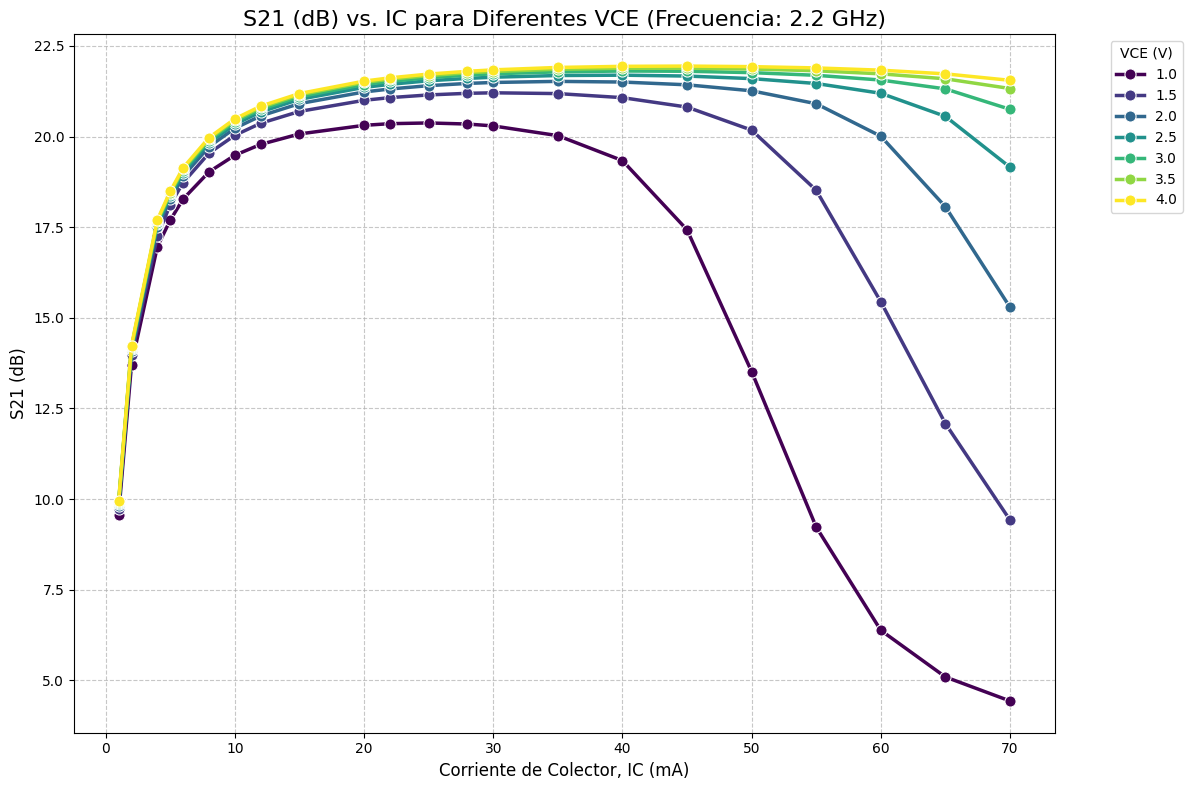

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que el DataFrame está ordenado para que las líneas se dibujen correctamente
df_s_parameters_sorted = df_s_parameters.sort_values(by=['VCE', 'IC'])

plt.figure(figsize=(12, 8))

sns.lineplot(
    data=df_s_parameters_sorted,
    x='IC',
    y=df_s_parameters_sorted['s21_complex'].apply(lambda x: 20 * np.log10(np.abs(x))), # Convertir a dB
    hue='VCE',
    marker='o', # Marcar los puntos de datos
    palette='viridis', # Una paleta de colores para VCE
    linewidth=2.5,
    markersize=8
)

plt.title('S21 (dB) vs. IC para Diferentes VCE (Frecuencia: 2.2 GHz)', fontsize=16)
plt.xlabel('Corriente de Colector, IC (mA)', fontsize=12)
plt.ylabel('S21 (dB)', fontsize=12) # Cambiar etiqueta del eje Y
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='VCE (V)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
df_s_parameters['s21_db'] = df_s_parameters['s21_complex'].apply(lambda x: 20 * np.log10(np.abs(x)))

print("DataFrame con la nueva columna 's21_db':")
display(df_s_parameters.head())

DataFrame con la nueva columna 's21_db':


,filename,network_name,frequency_ghz,VCE,IC,s11_mag,s21_mag,s12_mag,s22_mag,s11_deg,s21_deg,s12_deg,s22_deg,s11_complex,s21_complex,s12_complex,s22_complex,s21_db
0,BFP760_VCE_2.0V_IC_50mA.s2p,BFP760_VCE_2.0V_IC_50mA,2.0,2.0,50.0,0.6683,11.562,0.0367,0.2797,175.4,75.9,37.9,-152.0,-0.666147+0.053597j,2.816677+11.213660j,0.028959+0.022544j,-0.246960-0.131311j,21.260659
1,BFP760_w_noise_VCE_3.0V_IC_4.0mA.s2p,BFP760_w_noise_VCE_3.0V_IC_4.0mA,2.0,3.0,4.0,0.7337,7.606,0.0972,0.5816,-119.4,99.4,22.2,-79.2,-0.360176-0.639210j,-1.242257+ 7.503868j,0.089995+0.036726j,0.108981-0.571298j,17.623126
2,BFP760_VCE_4.0V_IC_28mA.s2p,BFP760_VCE_4.0V_IC_28mA,2.0,4.0,28.0,0.6407,12.299,0.0418,0.2930,-174.1,80.0,31.2,-134.1,-0.637306-0.065859j,2.135699+12.112151j,0.035754+0.021654j,-0.203902-0.210411j,21.797396
3,BFP760_w_noise_VCE_2.0V_IC_10mA.s2p,BFP760_w_noise_VCE_2.0V_IC_10mA,2.0,2.0,10.0,0.6647,10.265,0.0663,0.4057,-151.7,87.1,20.4,-112.1,-0.585253-0.315126j,0.519337+10.251854j,0.062142+0.023110j,-0.152634-0.375893j,20.227179
4,BFP760_VCE_1.5V_IC_60mA.s2p,BFP760_VCE_1.5V_IC_60mA,2.0,1.5,60.0,0.7860,5.918,0.0344,0.1871,167.1,71.9,36.8,-161.6,-0.766162+0.175475j,1.838583+ 5.625152j,0.027545+0.020606j,-0.177535-0.059058j,15.443499


### Ajustar opciones de visualización de Pandas

Por defecto, pandas trunca la visualización de DataFrames grandes. Podemos ajustar estas opciones para ver todas las filas y columnas si es necesario.

In [ ]:
pd.set_option('display.max_rows', None) # Muestra todas las filas
pd.set_option('display.max_columns', None) # Muestra todas las columnas
pd.set_option('display.width', 1000) # Asegura que el ancho de la pantalla sea suficiente

print("DataFrame completo con 's21_db':")
display(df_s_parameters)

DataFrame completo con 's21_db':


,filename,network_name,frequency_ghz,VCE,IC,s11_mag,s21_mag,s12_mag,s22_mag,s11_deg,s21_deg,s12_deg,s22_deg,s11_complex,s21_complex,s12_complex,s22_complex,s21_db
0,BFP760_VCE_2.0V_IC_50mA.s2p,BFP760_VCE_2.0V_IC_50mA,2.0,2.0,50.0,0.6683,11.562,0.0367,0.2797,175.4,75.9,37.9,-152.0,-0.666147+0.053597j,2.816677+11.213660j,0.028959+0.022544j,-0.246960-0.131311j,21.260659
1,BFP760_w_noise_VCE_3.0V_IC_4.0mA.s2p,BFP760_w_noise_VCE_3.0V_IC_4.0mA,2.0,3.0,4.0,0.7337,7.606,0.0972,0.5816,-119.4,99.4,22.2,-79.2,-0.360176-0.639210j,-1.242257+ 7.503868j,0.089995+0.036726j,0.108981-0.571298j,17.623126
2,BFP760_VCE_4.0V_IC_28mA.s2p,BFP760_VCE_4.0V_IC_28mA,2.0,4.0,28.0,0.6407,12.299,0.0418,0.2930,-174.1,80.0,31.2,-134.1,-0.637306-0.065859j,2.135699+12.112151j,0.035754+0.021654j,-0.203902-0.210411j,21.797396
3,BFP760_w_noise_VCE_2.0V_IC_10mA.s2p,BFP760_w_noise_VCE_2.0V_IC_10mA,2.0,2.0,10.0,0.6647,10.265,0.0663,0.4057,-151.7,87.1,20.4,-112.1,-0.585253-0.315126j,0.519337+10.251854j,0.062142+0.023110j,-0.152634-0.375893j,20.227179
4,BFP760_VCE_1.5V_IC_60mA.s2p,BFP760_VCE_1.5V_IC_60mA,2.0,1.5,60.0,0.7860,5.918,0.0344,0.1871,167.1,71.9,36.8,-161.6,-0.766162+0.175475j,1.838583+ 5.625152j,0.027545+0.020606j,-0.177535-0.059058j,15.443499
5,BFP760_w_noise_VCE_4.0V_IC_25mA.s2p,BFP760_w_noise_VCE_4.0V_IC_25mA,2.0,4.0,25.0,0.6407,12.193,0.0434,0.2999,-172.1,80.6,29.9,-131.5,-0.634619-0.088061j,1.991433+12.029274j,0.037623+0.021634j,-0.198720-0.224612j,21.722211
6,BFP760_w_noise_VCE_4.0V_IC_2.0mA.s2p,BFP760_w_noise_VCE_4.0V_IC_2.0mA,2.0,4.0,2.0,0.8124,5.150,0.1191,0.7286,-97.0,108.7,27.5,-61.4,-0.099007-0.806344j,-1.651157+ 4.878133j,0.105643+0.054994j,0.348775-0.639698j,14.236145
7,BFP760_VCE_1.0V_IC_55mA.s2p,BFP760_VCE_1.0V_IC_55mA,2.0,1.0,55.0,0.8450,2.894,0.0374,0.2381,165.2,70.8,33.3,175.0,-0.816966+0.215852j,0.951740+ 2.733025j,0.031259+0.020533j,-0.237194+0.020752j,9.229971
8,BFP760_VCE_3.5V_IC_28mA.s2p,BFP760_VCE_3.5V_IC_28mA,2.0,3.5,28.0,0.6430,12.242,0.0419,0.2977,-174.4,79.7,31.1,-135.6,-0.639931-0.062746j,2.188897+12.044721j,0.035878+0.021643j,-0.212699-0.208290j,21.757048
9,BFP760_VCE_4.0V_IC_65mA.s2p,BFP760_VCE_4.0V_IC_65mA,2.0,4.0,65.0,0.6550,12.201,0.0341,0.2459,174.6,76.5,41.8,-145.2,-0.652093+0.061641j,2.848267+11.863885j,0.025421+0.022729j,-0.201921-0.140338j,21.727909


### Gráfico de S21 (dB) vs. IC, separado por archivos con y sin 'w_noise'

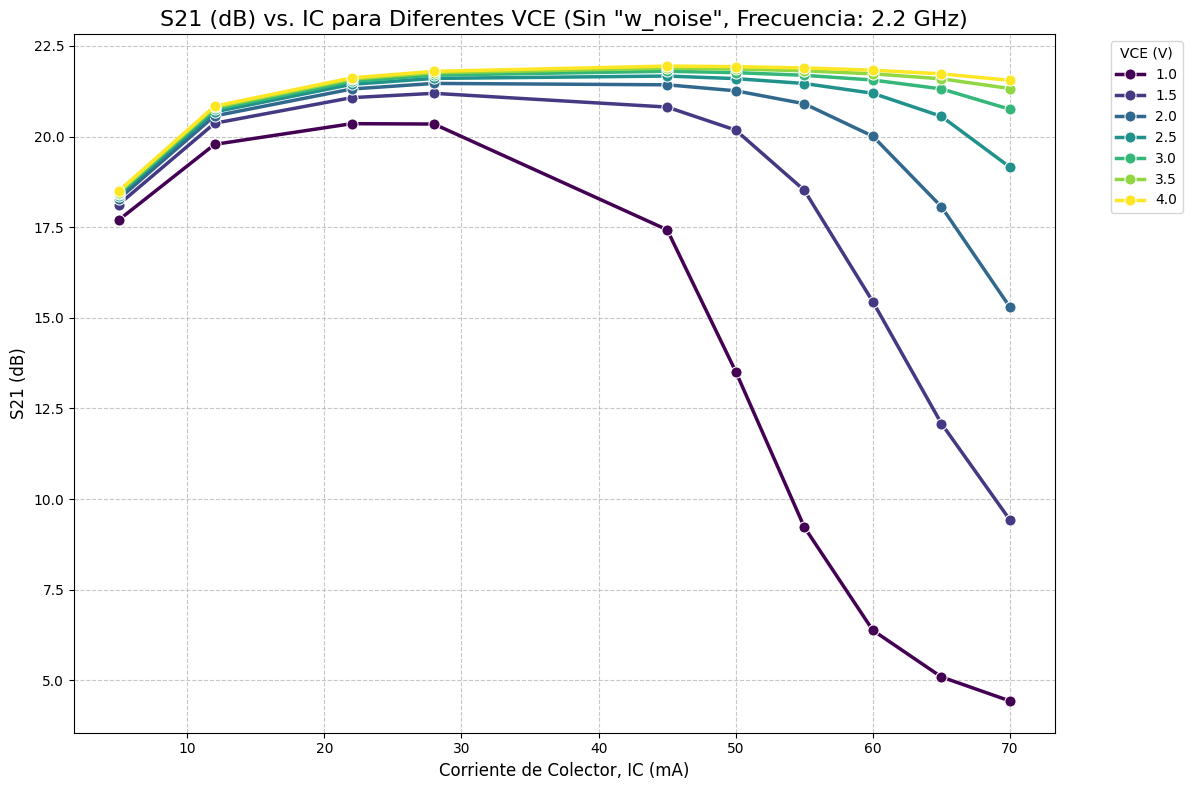

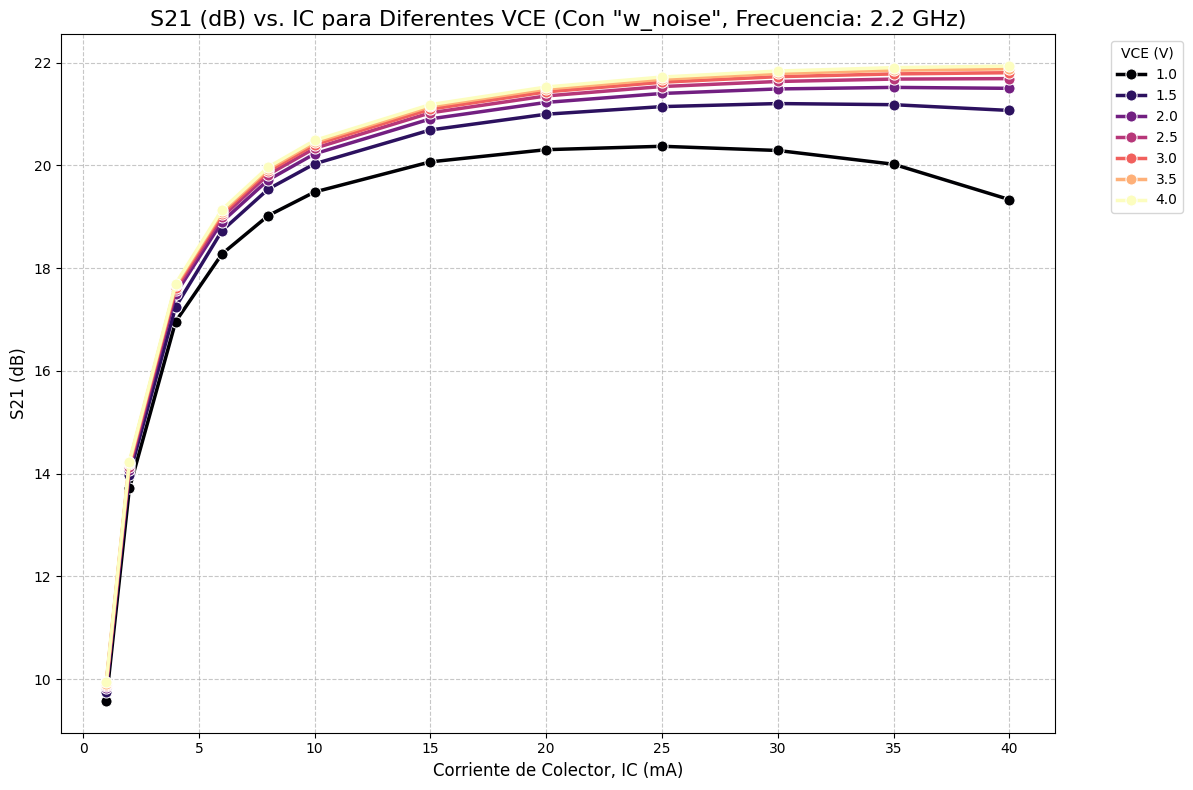

In [ ]:
# Filtrar el DataFrame en dos: con y sin 'w_noise'
df_with_noise = df_s_parameters[df_s_parameters['filename'].str.contains('w_noise')].sort_values(by=['VCE', 'IC'])
df_without_noise = df_s_parameters[~df_s_parameters['filename'].str.contains('w_noise')].sort_values(by=['VCE', 'IC'])

# --- Gráfico para archivos SIN 'w_noise' ---
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=df_without_noise,
    x='IC',
    y='s21_db',
    hue='VCE',
    marker='o',
    palette='viridis',
    linewidth=2.5,
    markersize=8
)
plt.title('S21 (dB) vs. IC para Diferentes VCE (Sin "w_noise", Frecuencia: 2.2 GHz)', fontsize=16)
plt.xlabel('Corriente de Colector, IC (mA)', fontsize=12)
plt.ylabel('S21 (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='VCE (V)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Gráfico para archivos CON 'w_noise' ---
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=df_with_noise,
    x='IC',
    y='s21_db',
    hue='VCE',
    marker='o',
    palette='magma',
    linewidth=2.5,
    markersize=8
)
plt.title('S21 (dB) vs. IC para Diferentes VCE (Con "w_noise", Frecuencia: 2.2 GHz)', fontsize=16)
plt.xlabel('Corriente de Colector, IC (mA)', fontsize=12)
plt.ylabel('S21 (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='VCE (V)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Gráfico de S21 (dB) vs. IC, diferenciando archivos con y sin 'w_noise' en un solo gráfico

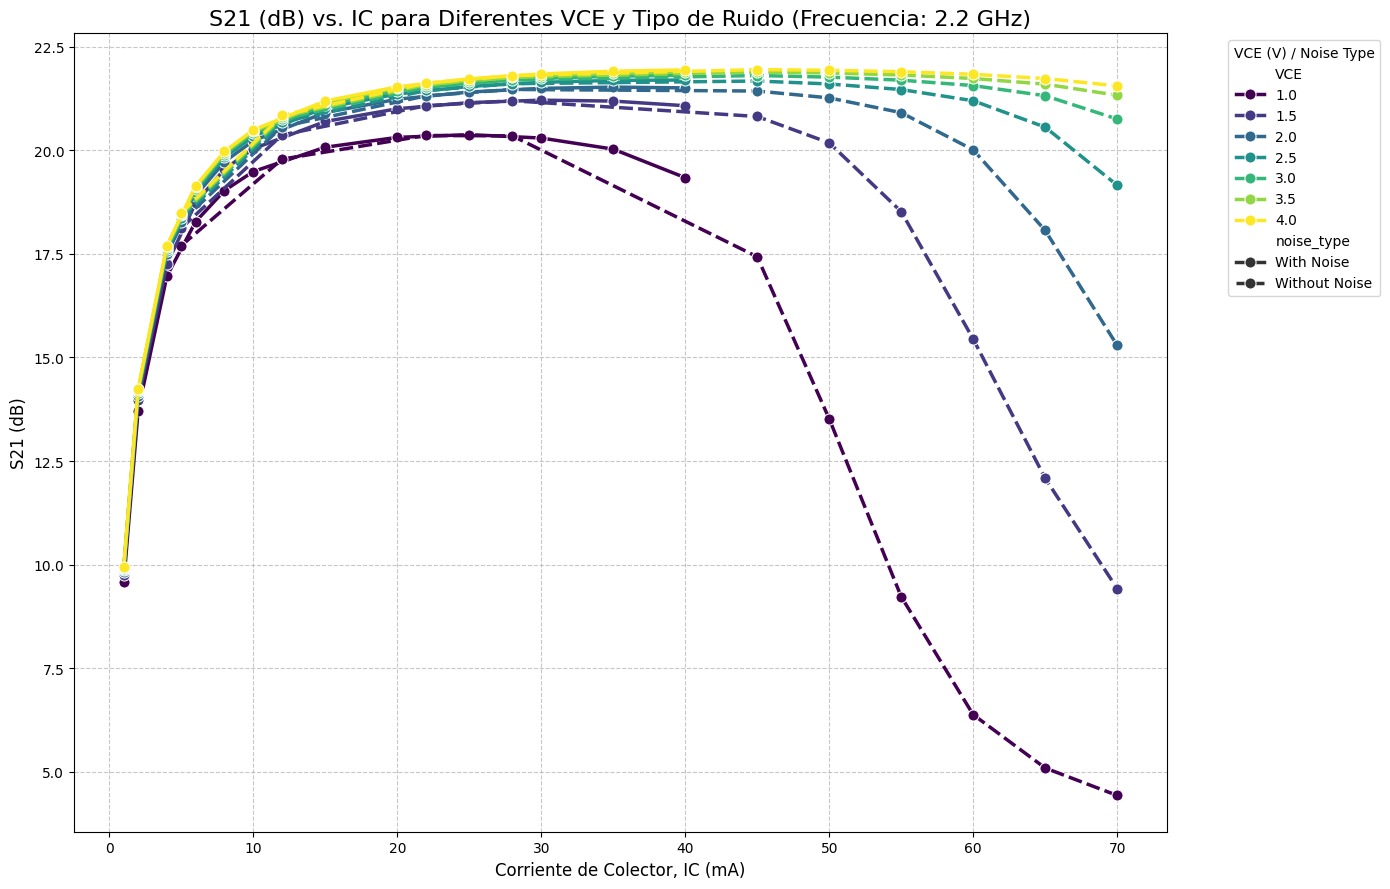

In [ ]:
# Crear una nueva columna para indicar si el archivo tiene 'w_noise'
df_s_parameters['noise_type'] = df_s_parameters['filename'].apply(lambda x: 'With Noise' if 'w_noise' in x else 'Without Noise')

# Asegurarse de que el DataFrame está ordenado para que las líneas se dibujen correctamente
df_s_parameters_sorted_combined = df_s_parameters.sort_values(by=['noise_type', 'VCE', 'IC'])

plt.figure(figsize=(14, 9))

sns.lineplot(
    data=df_s_parameters_sorted_combined,
    x='IC',
    y='s21_db',
    hue='VCE', # Colorear por VCE
    style='noise_type', # Diferenciar el estilo de línea por tipo de ruido
    marker='o', # Marcar los puntos de datos
    palette='viridis', # Una paleta de colores para VCE
    linewidth=2.5,
    markersize=8
)

plt.title('S21 (dB) vs. IC para Diferentes VCE y Tipo de Ruido (Frecuencia: 2.2 GHz)', fontsize=16)
plt.xlabel('Corriente de Colector, IC (mA)', fontsize=12)
plt.ylabel('S21 (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='VCE (V) / Noise Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

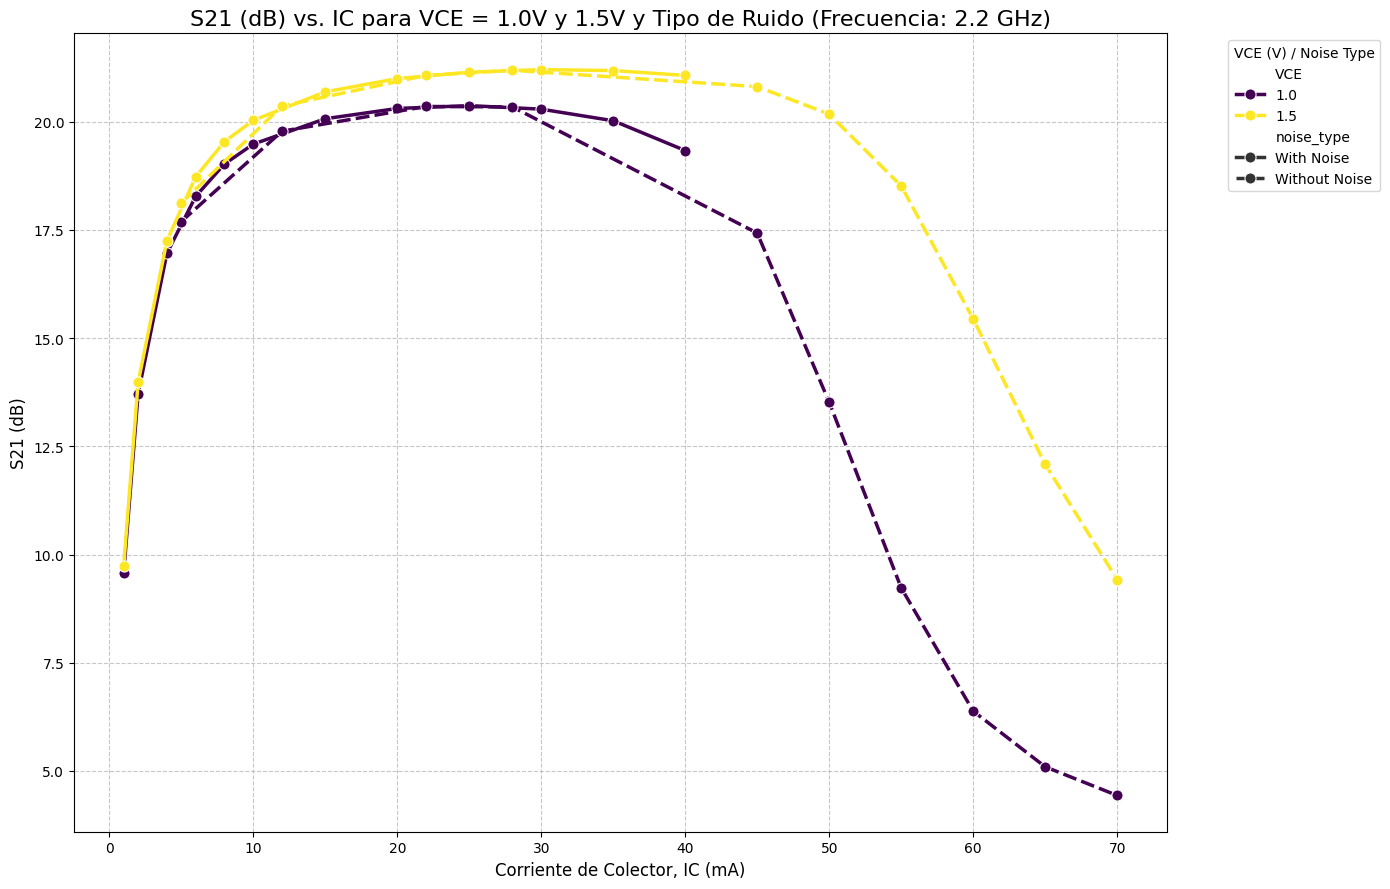

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtrar el DataFrame para VCE = 1.0V y VCE = 1.5V
df_filtered_vce = df_s_parameters[df_s_parameters['VCE'].isin([1.0, 1.5])]

# Asegurarse de que el DataFrame filtrado está ordenado para que las líneas se dibujen correctamente
df_filtered_vce_sorted = df_filtered_vce.sort_values(by=['noise_type', 'VCE', 'IC'])

plt.figure(figsize=(14, 9))

sns.lineplot(
    data=df_filtered_vce_sorted,
    x='IC',
    y='s21_db',
    hue='VCE', # Colorear por VCE
    style='noise_type', # Diferenciar el estilo de línea por tipo de ruido
    marker='o', # Marcar los puntos de datos
    palette='viridis', # Una paleta de colores para VCE
    linewidth=2.5,
    markersize=8
)

plt.title('S21 (dB) vs. IC para VCE = 1.0V y 1.5V y Tipo de Ruido (Frecuencia: 2.2 GHz)', fontsize=16)
plt.xlabel('Corriente de Colector, IC (mA)', fontsize=12)
plt.ylabel('S21 (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='VCE (V) / Noise Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()